In [1]:
!mkdir -p ~/.kaggle
!cp "kaggle.json" ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [2]:
# API to fetch the dataset from Kaggle
!kaggle datasets download -d omkargurav/face-mask-dataset

Dataset URL: https://www.kaggle.com/datasets/omkargurav/face-mask-dataset
License(s): unknown
100% 163M/163M [00:00<00:00, 255MB/s]



In [3]:
# extracting the compressed dataset
from zipfile import ZipFile

dataset = '/content/face-mask-dataset.zip'

with ZipFile(dataset, 'r') as zip:
    zip.extractall()
    print('The dataset is extracted')

The dataset is extracted


In [4]:
!ls

data  face-mask-dataset.zip  sample_data


In [5]:
!ls -lh


total 164M
drwxr-xr-x 4 root root 4.0K Jun 22 15:30 data
-rw-r--r-- 1 root root 164M Jul 31  2020 face-mask-dataset.zip
drwxr-xr-x 1 root root 4.0K Jun  4 13:39 sample_data


In [6]:
#importing the dependencies
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
from google.colab.patches import cv2_imshow
from PIL import Image
from sklearn.model_selection import train_test_split


In [11]:
import os
with_mask_files=os.listdir('/content/data/with_mask')
print(with_mask_files[0:5])
print(with_mask_files[-5:])

['with_mask_1314.jpg', 'with_mask_1848.jpg', 'with_mask_1728.jpg', 'with_mask_2291.jpg', 'with_mask_3081.jpg']
['with_mask_1285.jpg', 'with_mask_191.jpg', 'with_mask_2333.jpg', 'with_mask_1046.jpg', 'with_mask_300.jpg']


In [12]:
import os
without_mask_files=os.listdir('/content/data/without_mask')
print(without_mask_files[0:5])
print(without_mask_files[-5:])

['without_mask_1514.jpg', 'without_mask_2597.jpg', 'without_mask_1120.jpg', 'without_mask_2368.jpg', 'without_mask_1579.jpg']
['without_mask_1873.jpg', 'without_mask_1664.jpg', 'without_mask_1624.jpg', 'without_mask_3633.jpg', 'without_mask_1990.jpg']


In [13]:
print(len(with_mask_files))
print(len(without_mask_files))

3725
3828


In [15]:
#creatimg the labels for the two class of images
#with mask -->1
#without mask -->0
with_mask_labels=[1]*3725
without_mask_labels=[0]*3828

In [17]:
print(with_mask_labels[0:5])
print(without_mask_labels[0:5])

[1, 1, 1, 1, 1]
[0, 0, 0, 0, 0]


In [18]:
labels=with_mask_labels+without_mask_labels
print(len(labels))
print(labels[0:5])
print(labels[-5:])

7553
[1, 1, 1, 1, 1]
[0, 0, 0, 0, 0]


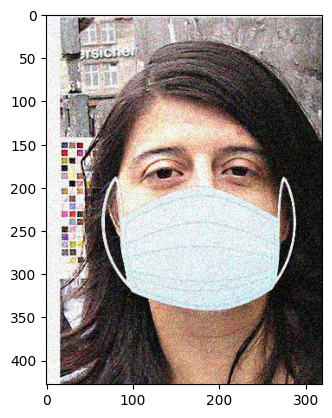

In [21]:
#displaying the size of the images
img=mpimg.imread('/content/data/with_mask/with_mask_1848.jpg')
imgplot=plt.imshow(img)
plt.show()

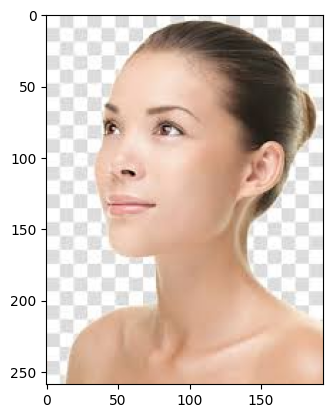

In [24]:
#displaying the size of the images
img=mpimg.imread('/content/data/without_mask/without_mask_2925.jpg')
imgplot=plt.imshow(img)
plt.show()

In [25]:
#image processing
#resize the image
#convert the images to the numpy array
with_mask_path='/content/data/with_mask/'
data=[]
for img_file in with_mask_files:
  image=Image.open(with_mask_path+img_file)
  image=image.resize((128,128)) #standard shape
  image=image.convert('RGB')
  image=np.array(image)
  data.append(image)

without_mask_path='/content/data/without_mask/'

for img_file in without_mask_files:
  image=Image.open(without_mask_path+img_file)
  image=image.resize((128,128)) #standard shape
  image=image.convert('RGB')
  image=np.array(image)
  data.append(image)




/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


In [27]:
type(data)

list

In [28]:
type(data[0])

numpy.ndarray

In [29]:
data[0].shape

(128, 128, 3)

In [30]:
X=np.array(data)
y=np.array(labels)

In [31]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=2)

In [32]:
#scaling the data
X_train_scaled=X_train/255
X_test_scaled=X_test/255

In [33]:
#building a convolutional neural network cnn
import tensorflow as tf
from tensorflow import keras



In [35]:
num_of_classes=2
model=keras.Sequential()
model.add(keras.layers.Conv2D(32,kernel_size=(3,3),activation='relu',input_shape=(128,128,3)))
model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))
model.add(keras.layers.Conv2D(64,kernel_size=(3,3),activation='relu'))
model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))
model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(128,activation='relu'))
model.add(keras.layers.Dropout(0.5))
model.add(keras.layers.Dense(64,activation='relu'))
model.add(keras.layers.Dropout(0.5))
model.add(keras.layers.Dense(num_of_classes,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [36]:
model.compile(optimizer='Adam',loss='sparse_categorical_crossentropy',metrics=['acc'])

In [37]:
#trainning the model
history=model.fit(X_train_scaled,y_train,validation_split=0.1,epochs=5)

Epoch 1/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 14s 43ms/step - acc: 0.7951 - loss: 0.4594 - val_acc: 0.9025 - val_loss: 0.2548
Epoch 2/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - acc: 0.8893 - loss: 0.2958 - val_acc: 0.8612 - val_loss: 0.2881
Epoch 3/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - acc: 0.9009 - loss: 0.2407 - val_acc: 0.9190 - val_loss: 0.2237
Epoch 4/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - acc: 0.9165 - loss: 0.2122 - val_acc: 0.9322 - val_loss: 0.1840
Epoch 5/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - acc: 0.9308 - loss: 0.1779 - val_acc: 0.8793 - val_loss: 0.2523


In [38]:
#model evaluation
loss,accuracy=model.evaluate(X_test_scaled,y_test)
print("test accuracy=",accuracy)
print("loss=",loss)

48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - acc: 0.8848 - loss: 0.2807
test accuracy= 0.8848444819450378
loss= 0.28068462014198303


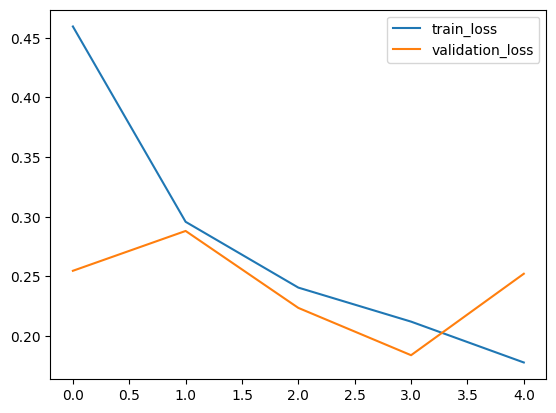

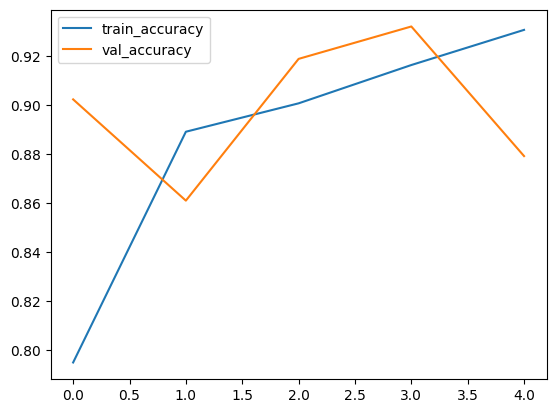

In [41]:
plt.plot(history.history['loss'],label='train_loss')
plt.plot(history.history['val_loss'],label='validation_loss')
plt.legend()
plt.show()

plt.plot(history.history['acc'],label='train_accuracy')
plt.plot(history.history['val_acc'],label='val_accuracy')
plt.legend()
plt.show()

Path of the image to be predicted: /content/mask.jpg


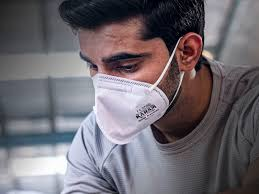

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Prediction probabilities: [[0.47856048 0.599935  ]]
Predicted label: 1
The person in the image is wearing the mask


In [49]:
# predictive system
input_image_path = input('Path of the image to be predicted: ')

input_image = cv2.imread(input_image_path)
cv2_imshow(input_image)

input_image_resized = cv2.resize(input_image, (128, 128))
input_image_scaled = input_image_resized / 255.0
input_image_reshape = np.reshape(input_image_scaled, [1, 128, 128, 3])

input_prediction = model.predict(input_image_reshape)
print("Prediction probabilities:", input_prediction)

input_pred_label = np.argmax(input_prediction, axis=1)[0]
print("Predicted label:", input_pred_label)

if input_pred_label == 1:
    print("The person in the image is wearing the mask")
else:
    print("The person in the image is NOT wearing the mask")